In [1]:
%run "../Model_Building/utls.ipynb"

(5410, 36)
(4328, 34)
(1082, 34)
PotentialFraud
0    3923
1     405
Name: count, dtype: int64
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [2]:
import pickle

In [5]:
with open('../Models/lgbm_desired.pkl', 'rb') as f:
    lgb_estimate = pickle.load(f)

In [7]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# STEP 1 — choose the right explainer for your model
# ─────────────────────────────────────────────

# Tree-based models (XGBoost, LightGBM, RandomForest, GradientBoosting)
# → fastest, most accurate for tree models
explainer = shap.TreeExplainer(lgb_estimate)

# Logistic Regression / Linear models
# explainer = shap.LinearExplainer(model, X_train)

# Any black-box model (Neural Network, SVM, etc.)
# explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_train, 100))

# ─────────────────────────────────────────────
# STEP 2 — compute SHAP values on test set
# ─────────────────────────────────────────────
claim_index =0 
shap_values = explainer.shap_values(x_test)

c:\Users\MK PERUMALLA\OneDrive\Desktop\Fraud_Analytics\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [8]:
# For binary classification (fraud = class 1), extract class 1 values
# TreeExplainer returns a list [class_0_values, class_1_values]
if isinstance(shap_values, list):
    shap_vals = shap_values[9]   # class 1 = fraud
else:
    shap_vals = shap_values
shap_vals

array([[-0.35373377, -0.19134981, -0.19279775, ...,  0.04157413,
         0.01413939, -0.1140752 ],
       [-0.52825855, -0.19336749, -0.29666341, ...,  0.00685091,
         0.01512473,  0.02113991],
       [-0.57857562, -0.17161645, -0.32196344, ...,  0.21618151,
         0.02639525,  0.0135233 ],
       ...,
       [-0.54100354, -0.24316344, -0.24918841, ...,  0.0032391 ,
         0.02868152,  0.01698993],
       [-0.53561898, -0.24691768, -0.23141956, ...,  0.0160699 ,
         0.05280179, -0.09700949],
       [-0.51439442, -0.16976415, -0.25786081, ...,  0.02587264,
         0.01382199,  0.01153924]], shape=(1082, 34))

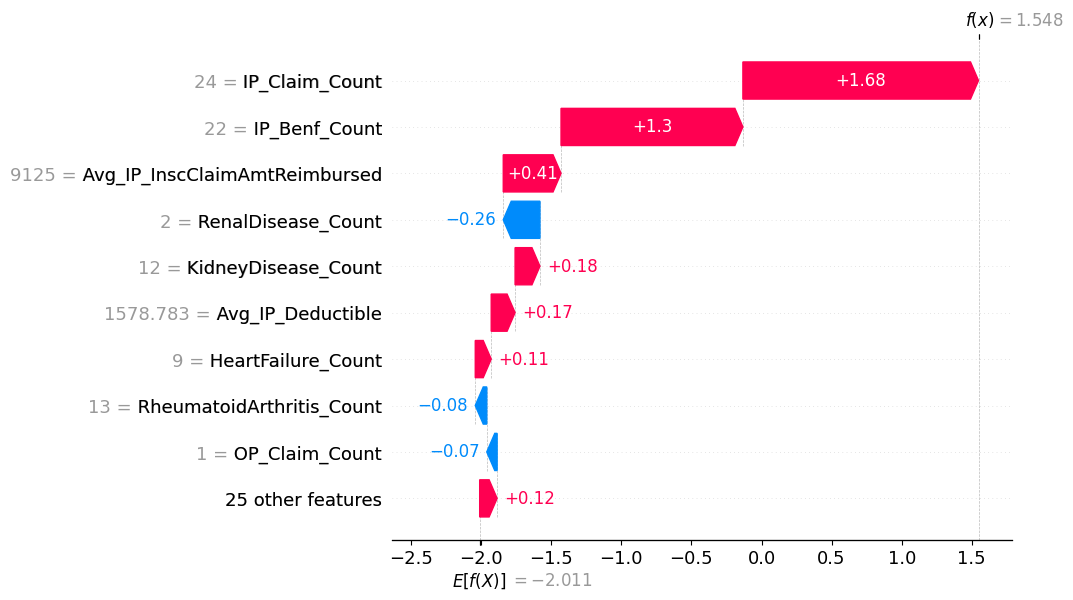

In [9]:
# ─────────────────────────────────────────────
# STEP 3 — single prediction waterfall
# (explains why one specific claim was flagged)
# ─────────────────────────────────────────────

claim_index = 8 # change to any row index you want to explain

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_vals[claim_index],
        base_values = explainer.expected_value if not isinstance(explainer.expected_value, list)
                      else explainer.expected_value[1],
        data        = x_test.iloc[claim_index],
        feature_names = x_test.columns.tolist()
    )
)

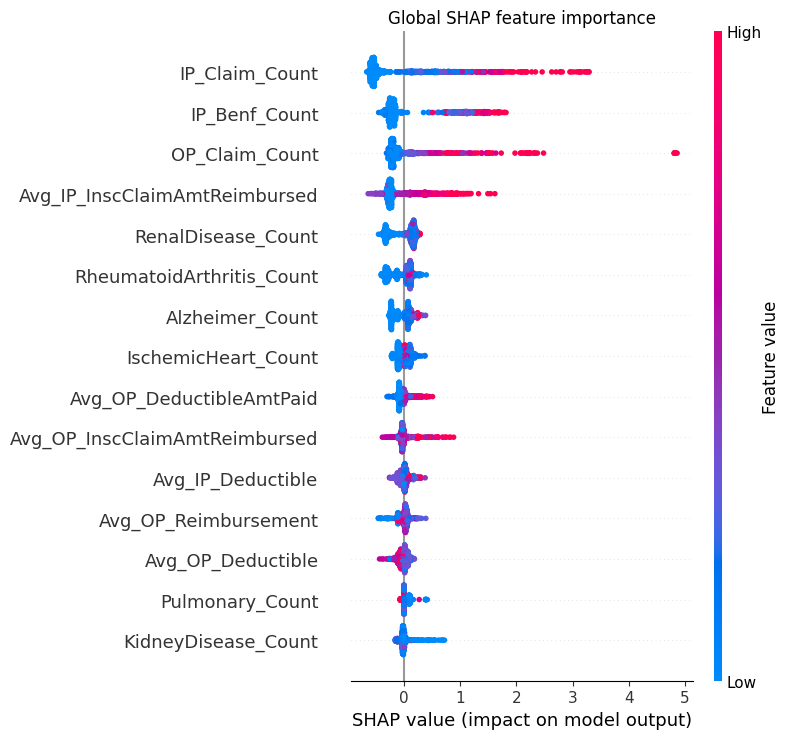

In [10]:
# ─────────────────────────────────────────────
# STEP 4 — global summary plot
# (shows which features matter most, and direction)
# ─────────────────────────────────────────────

plt.figure()
shap.summary_plot(
    shap_vals,
    x_test,
    feature_names = x_test.columns.tolist(),
    max_display   = 15,       # top 15 features
    show          = False
)
plt.title("Global SHAP feature importance")
plt.tight_layout()
plt.show()

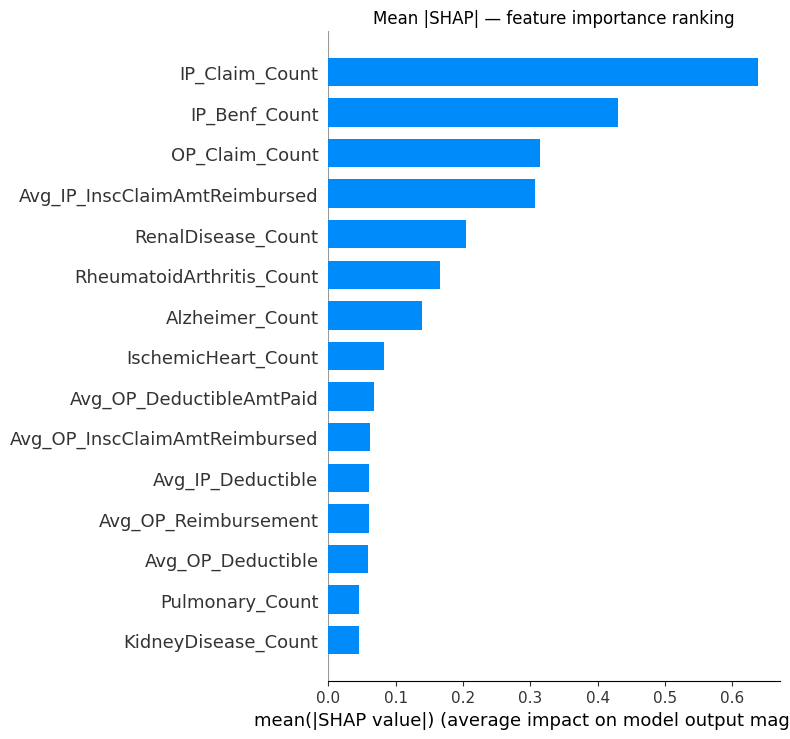

In [11]:

# ─────────────────────────────────────────────
# STEP 5 — mean absolute SHAP bar chart
# (clean ranked importance, easier to present)
# ─────────────────────────────────────────────

plt.figure()
shap.summary_plot(
    shap_vals,
    x_test,
    feature_names = x_test.columns.tolist(),
    plot_type     = "bar",
    max_display   = 15,
    show          = False
)
plt.title("Mean |SHAP| — feature importance ranking")
plt.tight_layout()
plt.show()


In [12]:
# ─────────────────────────────────────────────
# STEP 6 — export SHAP values as a DataFrame
# (useful for logging, auditing, threshold analysis)
# ─────────────────────────────────────────────

shap_df = pd.DataFrame(
    shap_vals,
    columns = [f"shap_{c}" for c in x_test.columns]
)
shap_df["predicted_fraud_prob"] = lgb_estimate.predict_proba(x_test)[:, 1]
shap_df["top_reason"] = shap_df[
    [f"shap_{c}" for c in x_test.columns]
].apply(lambda row: row.abs().idxmax().replace("shap_", ""), axis=1)

print(shap_df[["predicted_fraud_prob", "top_reason"]].head(10))

   predicted_fraud_prob      top_reason
0              0.497691  OP_Claim_Count
1              0.025562  IP_Claim_Count
2              0.030669  IP_Claim_Count
3              0.024096  IP_Claim_Count
4              0.016240  IP_Claim_Count
5              0.053941  IP_Claim_Count
6              0.062899  IP_Claim_Count
7              0.054158  OP_Claim_Count
8              0.824604  IP_Claim_Count
9              0.064382  IP_Claim_Count
